In [11]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Number of students
num_students = 100

# Generate sample data
data = {
    'Attendance': np.random.randint(60, 100, num_students),
    'Assignment_Score': np.random.randint(50, 100, num_students),
    'Midterm_Score': np.random.randint(45, 100, num_students),
    'Study_Hours': np.random.randint(1, 8, num_students)
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate final grade
df['Final_Grade'] = (
    0.25 * df['Attendance'] +
    0.30 * df['Assignment_Score'] +
    0.35 * df['Midterm_Score'] +
    2 * df['Study_Hours']
).round()

# Save dataset
df.to_csv('student_grades.csv', index=False)

# Display first five rows
df.head()

,Attendance,Assignment_Score,Midterm_Score,Study_Hours,Final_Grade
0,98,97,45,6,81.0
1,88,72,63,3,72.0
2,74,73,46,5,66.0
3,67,86,97,1,78.0
4,80,84,88,4,84.0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
X = df[['Attendance', 'Assignment_Score', 'Midterm_Score', 'Study_Hours']]
y = df['Final_Grade']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 0.22
R² Score: 1.0


In [13]:
# Example student data
new_student = [[90, 85, 88, 5]]

predicted_grade = model.predict(new_student)

print("Predicted Final Grade:", round(predicted_grade[0], 2))

Predicted Final Grade: 88.86


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


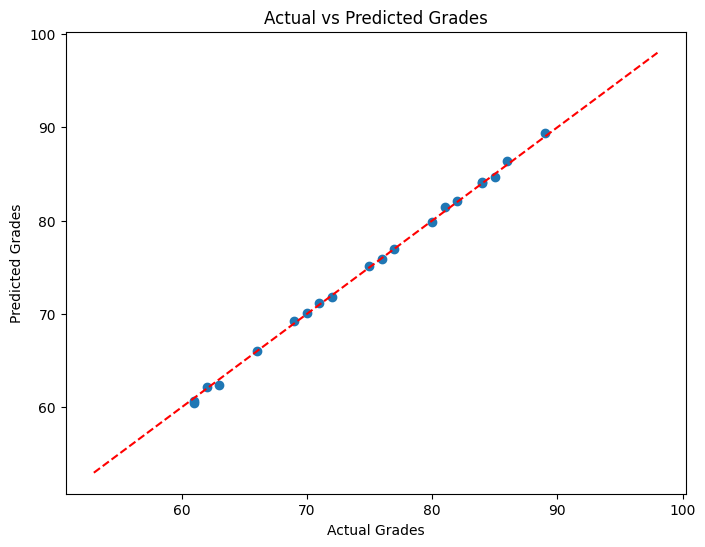

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()